# Stage 7: Purged K-Fold Cross-Validation
Implement PurgedKFold and combinatorial purged CV as sklearn-compatible splitters.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score
import sys
import os

sys.path.append('../')
from src.cross_validation import PurgedKFold, cv_score

plt.style.use('seaborn-v0_8-darkgrid')


## 1 & 2. Load Dataset and Extract Components


In [2]:
dataset = pd.read_parquet('../data/processed/nvda_modelling_dataset.parquet')

# Extract components
X = dataset.drop(columns=['label', 'weight', 't1'])
y = dataset['label']
sample_weight = dataset['weight']
t1 = dataset['t1']

print(f"X shape: {X.shape}, y shape: {y.shape}")


X shape: (171, 17), y shape: (171,)


## 3. Instantiate PurgedKFold


In [3]:
pkf = PurgedKFold(n_splits=5, t1=t1, pct_embargo=0.01)
print("Instantiated PurgedKFold")


Instantiated PurgedKFold


## 4 & 5. Run Purged CV with RandomForest


In [4]:
clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)

purged_scores = cv_score(clf, X, y, sample_weight, scoring='accuracy', cv=pkf)
print("Purged CV Accuracy Scores:")
print(purged_scores)
print(f"\nMean Accuracy: {purged_scores.mean():.4f}")
print(f"Std Accuracy: {purged_scores.std():.4f}")


Purged CV Accuracy Scores:
0    0.600000
1    0.617647
2    0.382353
3    0.411765
4    0.588235
dtype: float64

Mean Accuracy: 0.5200
Std Accuracy: 0.1132


## 6. Compare with Naive KFold


In [5]:
naive_kf = KFold(n_splits=5, shuffle=False)

# We fit without sample_weight for standard cross_val_score to keep it simple,
# or we can use our cv_score with standard KFold
naive_scores = cv_score(clf, X, y, sample_weight=None, scoring='accuracy', cv=naive_kf, t1=t1)

print("Naive CV Accuracy Scores (No Purging/Embargo/Weights):")
print(naive_scores)
print(f"\nMean Accuracy: {naive_scores.mean():.4f}")
print(f"Std Accuracy: {naive_scores.std():.4f}")
print(f"\nInflation Factor: {naive_scores.mean() - purged_scores.mean():.4f}")


Naive CV Accuracy Scores (No Purging/Embargo/Weights):
0    0.600000
1    0.735294
2    0.382353
3    0.411765
4    0.529412
dtype: float64

Mean Accuracy: 0.5318
Std Accuracy: 0.1439

Inflation Factor: 0.0118


## 7. Visualize Fold Composition


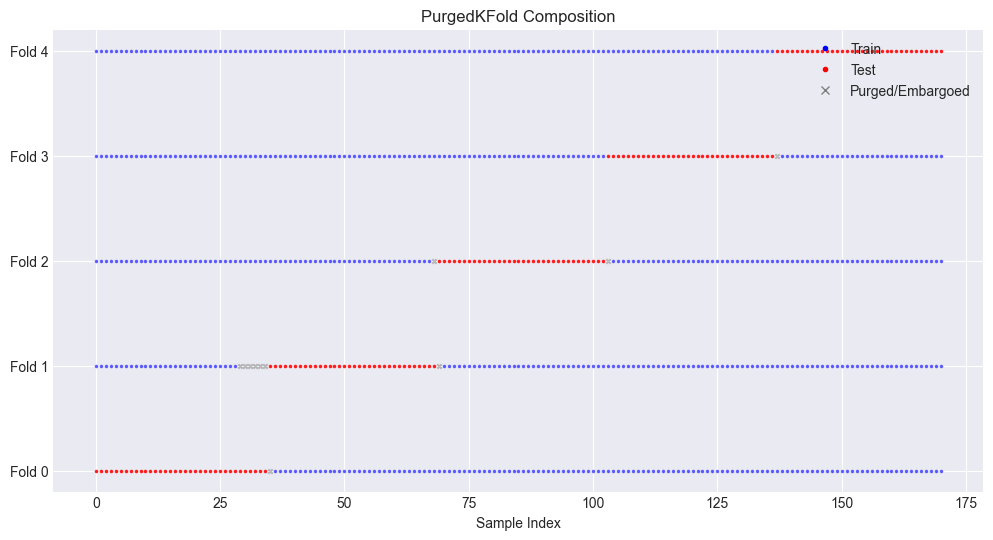

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

indices = np.arange(X.shape[0])
for fold, (train_idx, test_idx) in enumerate(pkf.split(X)):
    # Plot train
    ax.scatter(train_idx, [fold] * len(train_idx), color='blue', marker='.', s=10, alpha=0.5)
    # Plot test
    ax.scatter(test_idx, [fold] * len(test_idx), color='red', marker='.', s=10, alpha=0.8)
    
    # The purged and embargoed are the indices missing from both train and test
    all_fold_idx = np.concatenate([train_idx, test_idx])
    missing_idx = np.setdiff1d(indices, all_fold_idx)
    ax.scatter(missing_idx, [fold] * len(missing_idx), color='grey', marker='x', s=10, alpha=0.5)

# Custom legend
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='blue', marker='.', lw=0),
    Line2D([0], [0], color='red', marker='.', lw=0),
    Line2D([0], [0], color='grey', marker='x', lw=0)
]
ax.legend(custom_lines, ['Train', 'Test', 'Purged/Embargoed'], loc='upper right')

ax.set_yticks(range(5))
ax.set_yticklabels([f'Fold {i}' for i in range(5)])
ax.set_xlabel('Sample Index')
ax.set_title('PurgedKFold Composition')
plt.show()


## 8. Save Results


In [7]:
results = pd.DataFrame({
    'Purged_CV': purged_scores,
    'Naive_CV': naive_scores
})
results.to_csv('../data/processed/cv_results.csv', index=False)
print("Saved CV results to cv_results.csv")


Saved CV results to cv_results.csv
